# Caso de uso: Churn y probabilidad

In [2]:
# Importar las librerias

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [ ]:
# Carga de datos

#data set de clientes que dejaron de pagar la cuota de su credito
df = pd.read_csv('https://raw.githubusercontent.com/Haroldgio28/Probabilidad_de_impago/main/data/case%202/Churn%20Modeling.csv')

In [4]:
df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [ ]:
# Ahora se explora las caracteristicas del data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Descripcion

El dataset esta compuesto por 14 variables

| Variable        | Descripción                          | Tipo de variable          |
|-----------------|--------------------------------------|---------------------------|
| RowNumber       | Índice para el número de fila        | Cuantitativa discreta     |
| CustomerId      | Identificador único del cliente      | Cuantitativa discreta     |
| Surname         | Usuario del cliente                  | Cualitativa nominal       |
| CreditScore     | Puntaje del cliente                  | Cuantitativa discreta     |
| Geography       | Ubicación                            | Cualitativa nominal       |
| Gender          | Género                               | Cualitativa nominal       |
| Age             | Edad                                 | Cuantitativa discreta     |
| Tenure          | Tiempo con la cuenta                 | Cuantitativa discreta     |
| Balance         | Dinero en la cuenta                  | Cuantitativa continua     |
| NumOfProducts   | Número de productos con el banco     | Cuantitativa discreta     |
| HasCrCard       | Indicador si tiene tarjeta de crédito| Cuantitativa binaria      |
| IsActiveMember  | Indicador si es miembro activo       | Cuantitativa binaria      |
| EstimatedSalary | Salario aproximado                   | Cuantitativa continua     |
| Exited          | Cliente que dejó de pagar la cuota   | Cuantitativa binaria  |

## Probabilidad

In [ ]:
# Calculo de casos totales donde el cleunte no pago su cuota
'''
Para este caso el valor:
1 = No pago la cuota
0 = Cumplio con el pago
'''
df['Exited'].sum()

#--> Como resultado tenemos 2.037 casos donde los clientes no cumplieron con el pago

np.int64(2037)

In [ ]:
# Ahora se encuentra el numero total de los eventos en el data set

len(df['Exited'])

#--> Se encuentra que el numero total de eventos medidos son de 10.000 eventos

10000

In [ ]:
# PROBABILIDAD FRECUENTISTA -> PROBABILIDAD GENERAL
'''
Este tipo de probabilidad hace alucion a cuantas veces se repite
un evento en un conjunto de datos
'''

df['Exited'].sum() / len(df['Exited'])*100

#--> Se encuntra que el evento en donde el cliente no pago su cuento representa
#   el 20.37% de todos los registros del evento

np.float64(20.369999999999997)

### Comparacion entre variables

In [ ]:
# Se va a comprara las variables EXITED vs GEOGRAPHY

df['Geography'].value_counts(normalize=True)

#--> Se puede observar que Francia es el pais que tiene el 50.14% de los clientes

Geography
France     0.5014
Germany    0.2509
Spain      0.2477
Name: proportion, dtype: float64

In [ ]:
# Cantidad de clientes por pais

df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [ ]:
# Cantidad de casos de impago por pais

df.groupby('Geography')['Exited'].sum()

Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

In [ ]:
# Aqui se calcula la proporcian de casos de impago por pais

df.groupby('Geography')['Exited'].mean()*100

'''
Al calcular esta proporcion de no pagos o (impagos) por pais
Se encuentra que Germany tiene la tasa mas alta de no pagos con 32.44%
'''

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

<Axes: xlabel='Geography'>

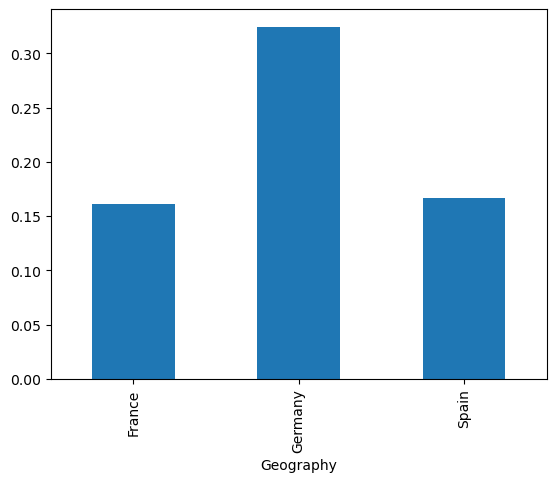

In [20]:
df.groupby('Geography')['Exited'].mean().plot(kind='bar')

In [21]:
# Ahora se va a comparar las variables GENERO vs EXITED

df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [23]:
df['Gender'].value_counts(normalize=True)*100

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

In [ ]:
# Se encuentra el total de eventos por cada genero

df.groupby('Gender')['Exited'].sum()

Gender
Female    1139
Male       898
Name: Exited, dtype: int64

In [ ]:
# Se encuentra la proporcion de no pago por parte de las mujeres

df.groupby('Gender')['Exited'].mean()*100

#--> Se ha encontrado que la proporcion de mujeres que no pagan es mayor a la de hombres

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [27]:
# hacemos un estudio de como se relacionan GEOGRAPHY con GENDER y la variables EXITED

df.groupby(['Geography','Gender'])['Exited'].mean()*100

Geography  Gender
France     Female    20.344980
           Male      12.713404
Germany    Female    37.552389
           Male      27.811550
Spain      Female    21.212121
           Male      13.112392
Name: Exited, dtype: float64

In [28]:
# AHora se compara las variables AGE y EXITED

df.Age.describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

<Axes: xlabel='Exited', ylabel='Age'>

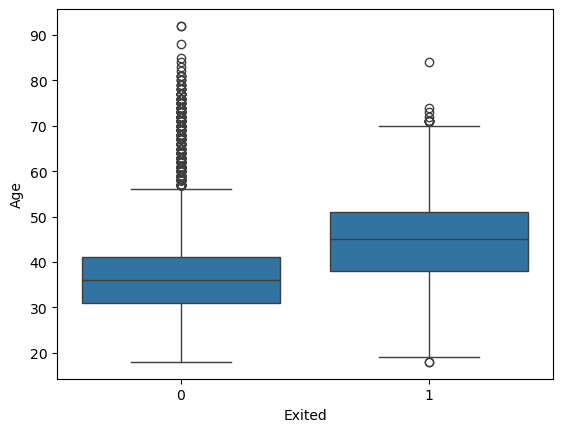

In [30]:
sns.boxplot(
    data= df,
    x = 'Exited',
    y= 'Age'
)

<Axes: xlabel='Exited', ylabel='Age'>

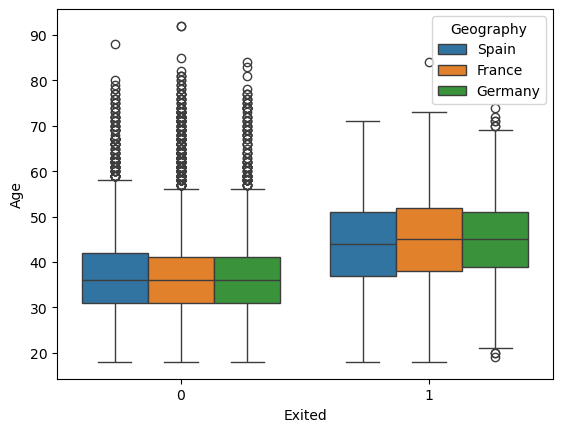

In [29]:
sns.boxplot(
    data= df,
    x = 'Exited',
    y= 'Age',
    hue='Geography'
)

In [31]:
# ¿ Hay relacion entre la edad y ubicacion ?

# ¿ Las coclusiones cambian si se analiza en funcion de edad, ubicacion y genero ?

## Discretizacion

La discretizacion consiste en convertir una variables en este caso cuantitativa continua (osea decimales) a unos valores que pueden ser categorizos o cuantitativos entre 0 y 1 normalmente

In [33]:
df['flag_joven_adulto'] = df['Age'].apply(
    lambda edad : 'Joven' if isinstance(edad, int) and 18 <= edad <=28
        else ('Adulto' if isinstance(edad, int) and edad > 28
            else ('No valido' if isinstance(edad, int)
                else 'Valor no valido')) 
)


df['flag_joven_adulto'].sample(5)

9220    Adulto
8444    Adulto
2277    Adulto
6970    Adulto
7713    Adulto
Name: flag_joven_adulto, dtype: object

In [34]:
df['flag_joven_adulto'].value_counts()

flag_joven_adulto
Adulto    8707
Joven     1293
Name: count, dtype: int64

In [36]:
df['flag_joven_adulto'].value_counts(normalize=True)*100

flag_joven_adulto
Adulto    87.07
Joven     12.93
Name: proportion, dtype: float64

<Axes: xlabel='Exited', ylabel='Age'>

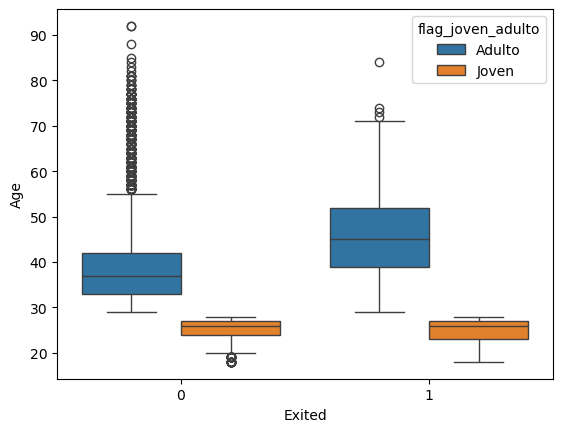

In [37]:
sns.boxplot(
    data= df,
    x = 'Exited',
    y= 'Age',
    hue='flag_joven_adulto'
)